In [2]:
#packages and reqs
import torch
import sentence_transformers #as it given in the HW
import sklearn
import rank_bm25
import pandas as pd
import numpy as np

print(f"torch: {torch.__version__}")
print(f"sentence-transformers: {sentence_transformers.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"rank-bm25: installed")
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")

torch: 2.11.0+cpu
sentence-transformers: 5.4.1
scikit-learn: 1.8.0
rank-bm25: installed
pandas: 3.0.2
numpy: 2.4.4


In [3]:
#random seed
import random
SEED = 42 
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
print(f"Seed set to {SEED}")

Seed set to 42


In [4]:
#loading documnents
import sys
sys.path.insert(0, '.')
from documents import iso_5338_summaries

doc_keys = list(iso_5338_summaries.keys())
doc_texts = list(iso_5338_summaries.values())
doc_id_map = {k:i for i, k in enumerate(doc_keys)}

print(f"Total documents: {len(doc_keys)}")
print("First 3 keys: ", doc_keys[:3])

Total documents: 33
First 3 keys:  ['Acquisition Process (6.1.1)', 'Supply Process (6.1.2)', 'Life Cycle Model Management Process (6.2.1)']


In [5]:
#csv
df = pd.read_csv('td_cases_train_4.csv')
df = df.rename(columns={'Unnamed: 0':'idx'})

print(df.shape)
df.head(3)

(365, 5)


,idx,case_description,root_cause,golden_doc,golden_id
0,0,Inability to obtain the data scraped from comm...,Data formats change over time in the third-par...,Design Definition Process (6.4.5),20
1,1,Ambiguity in the labeling protocol,-,System Requirements Definition Process (6.4.3),18
2,2,"Problems in data retrieval via API, such as in...",Poor data pipeline decisions,Decision Management Process (6.3.3),10


In [6]:
#creating query column

def query_text(row):
    rc = str(row['root_cause']) if str (row['root_cause']) != '_' else ''
    return str(row['case_description']) + ' ' + rc

df['query'] = df.apply(query_text, axis=1)
print(df['query'].head(3).to_string())

0    Inability to obtain the data scraped from comm...
1                 Ambiguity in the labeling protocol -
2    Problems in data retrieval via API, such as in...


In [7]:
#loading the model and embed the documents
from sentence_transformers import SentenceTransformer, util

model = SentenceTransformer('all-MiniLM-L6-v2')

doc_embeddings = model.encode(doc_texts, convert_to_tensor=True, show_progress_bar=True)
print("Document embeddings shape:", doc_embeddings.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Document embeddings shape: torch.Size([33, 384])


In [8]:
#moving onto part 1
#first question: Whether each document is referenced by queries more than once?
ref_counts = df['golden_doc'].value_counts()
print(ref_counts.to_string())

golden_doc
AI Data Engineering Process (6.4.8)                              64
Quality Assurance Process (6.3.8)                                48
System Requirements Definition Process (6.4.3)                   30
Implementation Process (6.4.9)                                   22
Risk Management Process (6.3.4)                                  22
Project Planning Process (6.3.1)                                 20
Configuration Management Process (6.3.5)                         17
Acquisition Process (6.1.1)                                      17
Quality Management Process (6.2.5)                               13
Human Resource Management Process (6.2.4)                        13
Design Definition Process (6.4.5)                                12
Decision Management Process (6.3.3)                              11
Infrastructure Management Process (6.2.2)                        11
Knowledge Management Process (6.2.6)                             10
Operation Process (6.4.15)           

In [9]:
#part1 second q:  Whether there are documents that are not referenced by any query. 
never_referenced = [k for k in doc_keys if k not in ref_counts.index]
print(f"Never referenced ({len(never_referenced)} docs):")
for d in never_referenced:
    print(' -',d)

Never referenced (8 docs):
 - Supply Process (6.1.2)
 - Life Cycle Model Management Process (6.2.1)
 - Measurement Process (6.3.7)
 - Business or Mission Analysis Process (6.4.1)
 - System Architecture Definition Process (6.4.4)
 - System Analysis Process (6.4.6)
 - Knowledge Acquisition Process (6.4.7)
 - Disposal Process (6.4.17)


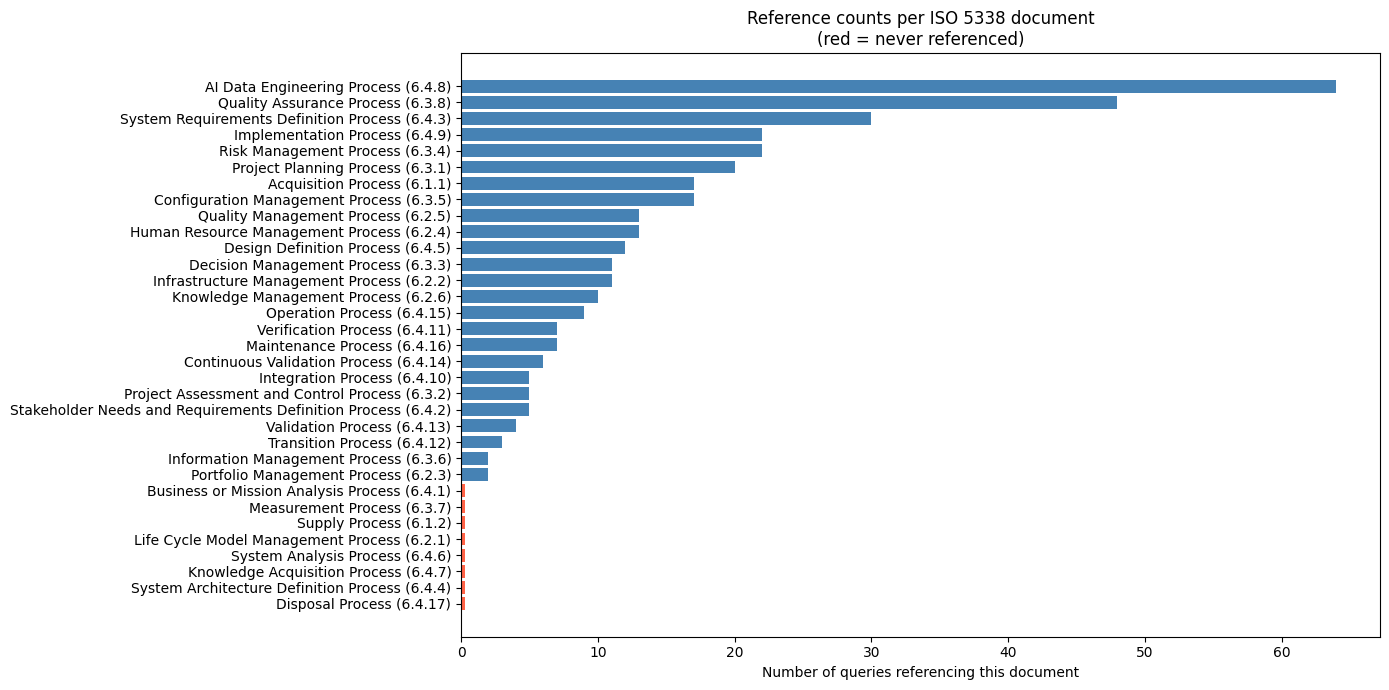

In [10]:
#bar chart for the analysis
import matplotlib.pyplot as plt
all_ref = pd.Series({k: ref_counts.get(k, 0) for k in doc_keys})
all_ref_sorted = all_ref.sort_values(ascending=False)

colors = ['steelblue' if v > 0 else 'tomato' for v in all_ref_sorted.values]

display_values = [v if v>0 else 0.3 for v in all_ref_sorted.values] #i make 0's to 0.3 so that we can see  their values so its made just for visualisation
fig, ax = plt.subplots(figsize=(14, 7))
ax.barh(all_ref_sorted.index, display_values, color=colors)
ax.set_xlabel('Number of queries referencing this document')
ax.set_title('Reference counts per ISO 5338 document\n(red = never referenced)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('fig_ref_counts.png', dpi=300) #in the HW it is given as DPI >= 300
plt.show()

In [11]:
#part 1 3rd q:  Whether the queries and their associated documents share keywords or concepts?
#i'm gonna calculate cosine similarity using tf-idf, and compare everyquery with its own golden doc

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

overlap_scores = []
for _, row in df.iterrows():
    q = row['query']
    doc = iso_5338_summaries[row['golden_doc']]
    tfidf = TfidfVectorizer(stop_words = 'english')
    mat = tfidf.fit_transform([q, doc])
    sim = cosine_similarity(mat[0], mat[1]) [0][0]
    overlap_scores.append(sim)

df['tfidf_overlap'] = overlap_scores

print(f"Mean: {np.mean(overlap_scores): .4f}")
print(f"Median: {np.median(overlap_scores): .4f}")
print(f"std: {np.std(overlap_scores):.4f}")

Mean:  0.0882
Median:  0.0512
std: 0.1036


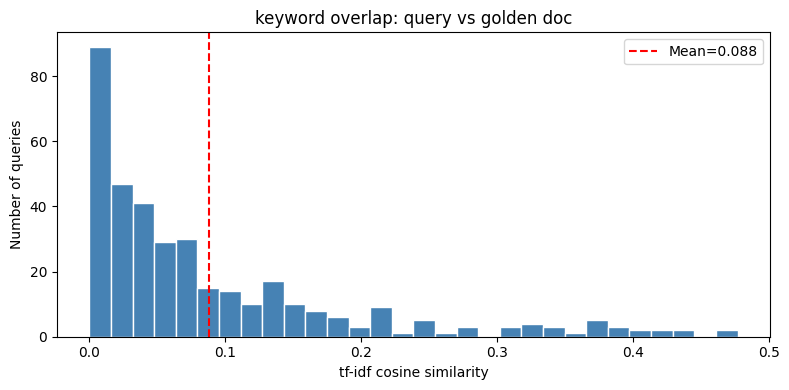

In [12]:
#histogram plot
fig, ax = plt.subplots(figsize=(8,4))
ax.hist(overlap_scores, bins =30, color='steelblue', edgecolor='white')
ax.axvline(np.mean(overlap_scores), color='red', linestyle='--', label=f'Mean={np.mean(overlap_scores):.3f}')
ax.set_xlabel('tf-idf cosine similarity')
ax.set_ylabel('Number of queries')
ax.set_title('keyword overlap: query vs golden doc')
ax.legend()
plt.tight_layout()
plt.savefig('fig_tfidf_overlap.png', dpi=300)
plt.show()

In [13]:
#PART 2 
query_embeddings = model.encode(df['query'].tolist(), convert_to_tensor=True, show_progress_bar=True)
print("query embeddings shape:", query_embeddings.shape)                                

Batches:   0%|          | 0/12 [00:00<?, ?it/s]

query embeddings shape: torch.Size([365, 384])


In [14]:
#calc cosine similarity and create ranked list
cosine_scores = util.cos_sim(query_embeddings, doc_embeddings) #365, 365
ranked_indices = torch.argsort(cosine_scores, dim=1, descending=True).cpu().numpy()

print("cosine_scores shape:", cosine_scores.shape)
print("ranked_indices shape:", ranked_indices.shape)

cosine_scores shape: torch.Size([365, 33])
ranked_indices shape: (365, 33)


In [15]:
def hit_at_k(ranked, golden_id, k):
    return int(golden_id in ranked[:k].tolist())

def ndcg_at_k(ranked, golden_id, k):
    top_k = ranked[:k].tolist()
    if golden_id not in top_k:
        return 0.0
    rank = list(top_k).index(golden_id) +1
    dcg = 1.0 / np.log2(rank +1)
    idcg = 1.0/np.log2(1+1)
    return dcg/idcg

def compute_metrics(ranked_indices, golden_ids, ks=(1, 3, 5)):
    results = {}
    for k in ks: 
        hits = [hit_at_k(r, g, k) for r, g in zip(ranked_indices, golden_ids)]
        ndcgs = [ndcg_at_k(r, g, k) for r, g in zip(ranked_indices, golden_ids)]
        results[f'Hit@{k}'] = np.mean(hits)
        results[f'NDCG@{k}'] = np.mean(ndcgs)
    return results
print("metrics function defined")

metrics function defined


In [16]:
golden_ids = df['golden_id'].tolist()

dense_metrics = compute_metrics(ranked_indices, golden_ids)
print("dense retrieval metrics:")
for k, v, in dense_metrics.items():
    print(f" {k}: {v:.4f}")

dense retrieval metrics:
 Hit@1: 0.1178
 NDCG@1: 0.1178
 Hit@3: 0.3068
 NDCG@3: 0.2245
 Hit@5: 0.4000
 NDCG@5: 0.2627


In [17]:
#failure case
failure_cases = []
for i, (ranked, gid) in enumerate(zip(ranked_indices, golden_ids)):
    rank = list(ranked).index(gid)+1
    if rank > 5:
        failure_cases.append({
            'row_idx': i,
            'golden_rank': rank,
            'golden_doc': df.iloc[i]['golden_doc'],
            'top1_doc': doc_keys[ranked[0]],
            'case_description': df.iloc[i]['case_description'],
            'root_cause': df.iloc[i]['root_cause'],
        })
print(f"total failure cases (rank > 5): {len(failure_cases)}")
print(f"first 5:")
for fc in failure_cases[:5]:
    print(f"\n  Row {fc['row_idx']} | Rank: {fc['golden_rank']}")
    print(f"  Golden: {fc['golden_doc']}")
    print(f"  Top-1: {fc['top1_doc']}")
    print(f"  Case: {fc['case_description']}")
    print(f"  Cause: {fc['root_cause']}")


total failure cases (rank > 5): 219
first 5:

  Row 0 | Rank: 26
  Golden: Design Definition Process (6.4.5)
  Top-1: Business or Mission Analysis Process (6.4.1)
  Case: Inability to obtain the data scraped from commercial sites
  Cause: Data formats change over time in the third-party data source

  Row 2 | Rank: 13
  Golden: Decision Management Process (6.3.3)
  Top-1: AI Data Engineering Process (6.4.8)
  Case: Problems in data retrieval via API, such as incorrect parsing, fetching unnecessary data, and not testing data acquisition
  Cause: Poor data pipeline decisions

  Row 3 | Rank: 6
  Golden: Validation Process (6.4.13)
  Top-1: Project Planning Process (6.3.1)
  Case: Lack of comprehensive testing in ML projects before deployment
  Cause: The need for testers specifically in the ML domain

  Row 4 | Rank: 14
  Golden: AI Data Engineering Process (6.4.8)
  Top-1: Measurement Process (6.3.7)
  Case: Out-of-distribution (OOD) examples or novelty detection
  Cause: Pandemic affec

In [18]:
selected_failures = failure_cases[:5]
print("5 failure cases saved")

5 failure cases saved


In [19]:
import wandb
wandb.login() #wandb integration

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\ozgu.ozkan\_netrc.
wandb: Network error (SSLError), entering retry loop.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


True

In [20]:
import re
from rank_bm25 import BM25Okapi

def tokenize(text):
    return re.sub(r'[^a-zA-Z0-9 ]', ' ', text.lower()).split() #regex

tokenized_docs =[tokenize(d) for d in doc_texts]
bm25 = BM25Okapi(tokenized_docs)
print("BM25 index built")

BM25 index built


In [21]:
def hybrid_retrieve(query_text, query_emb, alpha, bm25, doc_embeddings):
    #bm25 scores
    bm25_raw = np.array(bm25.get_scores(tokenize(query_text)), dtype=np.float32)
    bm25_min, bm25_max = bm25_raw.min(), bm25_raw.max()
    if bm25_max - bm25_min > 0:
        bm25_norm = np.zeros_like(bm25_raw)

    cos_raw = util.cos_sim(query_emb, doc_embeddings).cpu().numpy().flatten().astype(np.float32) #dense cosine scores
    cos_min, cos_max = cos_raw.min(), cos_raw.max()
    if cos_max - cos_min > 0:
        cos_norm = (cos_raw - cos_min) / (cos_max - cos_min)
        if cos_max - cos_min > 0:
            cos_norm = (cos_raw - cos_min) / (cos_max - cos_min)
        else:
            cos_norm = np.zeros_like(cos_raw)

        combined = alpha * bm25_norm + (1 - alpha) * cos_norm
        return np.argsort(combined)[:: -1]

print("hybrid retriever defined")                    

hybrid retriever defined


In [22]:
import os

os.environ["WANDB_ENTITY"] = "ozgukan"
os.environ["WANDB_PROJECT"] = "nlp_assign3"

In [23]:
alpha_values = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
sweep_results = []
for alpha in alpha_values:
    run = wandb.init(
        project="nlp_assign3",
        entity="ozgukan",
        name=f"alpha_{alpha:.1f}",
        config={'alpha': alpha, 'model': 'all-MiniLM-L6-v2'},
        reinit=True
    )
    ranked_hybrid = []
    for i, row in df.iterrows():
        ranked = hybrid_retrieve(row['query'], query_embeddings[i], alpha, bm25, doc_embeddings)
        ranked_hybrid.append(ranked)

    metrics = compute_metrics(ranked_hybrid, golden_ids)
    metrics['alpha'] = alpha
    sweep_results.append(metrics)
    wandb.log(metrics)
    run.finish()
    print(f"alpha={alpha:.1f}  Hit@1={metrics['Hit@1']:.4f}  Hit@5={metrics['Hit@5']:.4f}")
sweep_df = pd.DataFrame(sweep_results).set_index('alpha')
print("\nsweep complete")

wandb: Network error (SSLError), entering retry loop.


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Hit@1,▁
Hit@3,▁
Hit@5,▁
NDCG@1,▁
NDCG@3,▁
NDCG@5,▁
alpha,▁
Hit@1,0.11781
Hit@3,0.30685
Hit@5,0.4
NDCG@1,0.11781


alpha=0.0  Hit@1=0.1178  Hit@5=0.4000


wandb: Network error (SSLError), entering retry loop.


...

Hit@1,▁
Hit@3,▁
Hit@5,▁
NDCG@1,▁
NDCG@3,▁
NDCG@5,▁
alpha,▁
Hit@1,0.11781
Hit@3,0.30685
Hit@5,0.4
NDCG@1,0.11781


alpha=0.9  Hit@1=0.1178  Hit@5=0.4000


wandb: Network error (SSLError), entering retry loop.


Hit@1,▁
Hit@3,▁
Hit@5,▁
NDCG@1,▁
NDCG@3,▁
NDCG@5,▁
alpha,▁
Hit@1,0
Hit@3,0.04384
Hit@5,0.07123
NDCG@1,0


alpha=1.0  Hit@1=0.0000  Hit@5=0.0712

sweep complete


In [24]:
print(sweep_df.to_string())

          Hit@1    NDCG@1     Hit@3    NDCG@3     Hit@5    NDCG@5
alpha                                                            
0.0    0.117808  0.117808  0.306849  0.224525  0.400000  0.262722
0.1    0.117808  0.117808  0.306849  0.224525  0.400000  0.262722
0.2    0.117808  0.117808  0.306849  0.224525  0.400000  0.262722
0.3    0.117808  0.117808  0.306849  0.224525  0.400000  0.262722
0.4    0.117808  0.117808  0.306849  0.224525  0.400000  0.262722
0.5    0.117808  0.117808  0.306849  0.224525  0.400000  0.262722
0.6    0.117808  0.117808  0.306849  0.224525  0.400000  0.262722
0.7    0.117808  0.117808  0.306849  0.224525  0.400000  0.262722
0.8    0.117808  0.117808  0.306849  0.224525  0.400000  0.262722
0.9    0.117808  0.117808  0.306849  0.224525  0.400000  0.262722
1.0    0.000000  0.000000  0.043836  0.024429  0.071233  0.035748


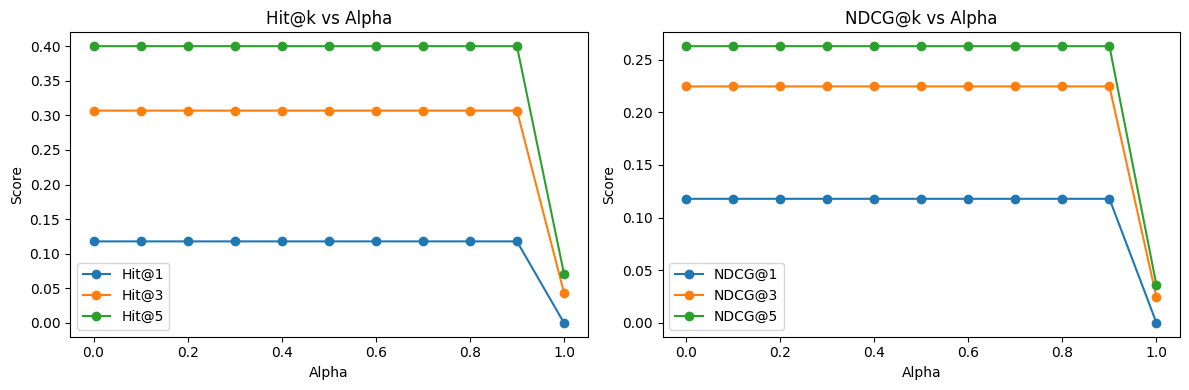

In [25]:
#visualisation
fig, axes = plt.subplots(1, 2, figsize=(12,4))
for metric in ['Hit@1', 'Hit@3', 'Hit@5']:
    axes[0].plot(sweep_df.index, sweep_df[metric], marker='o', label=metric)
axes[0].set_xlabel('Alpha')
axes[0].set_ylabel('Score')
axes[0].set_title('Hit@k vs Alpha')
axes[0].legend()

for metric in ['NDCG@1', 'NDCG@3', 'NDCG@5']:
    axes[1].plot(sweep_df.index, sweep_df[metric], marker='o', label=metric)
axes[1].set_xlabel('Alpha')
axes[1].set_ylabel('Score')
axes[1].set_title('NDCG@k vs Alpha')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig_alpha_sweep.png', dpi=300)
plt.show()

In [26]:
best_alpha = sweep_df['Hit@1'].idxmax()
print(f"Best alpha by Hit@1: {best_alpha}")

Best alpha by Hit@1: 0.0


In [27]:
#i am using ollama for part 4
import requests

response = requests.post(
    "http://localhost:11434/api/generate",
    json={
        "model": "llama3.2",
        "prompt": "Say hello!",
        "stream": False
    }
)
print(response.json()['response'])

Hello! It's nice to meet you. Is there something I can help you with or would you like to chat?


In [28]:
# prompts

SYSTEM_PROMPT = """You are an expert in ISO/IEC 5338:2023, the international standard for AI system life cycle processes.
Your task is to rephrase practitioner descriptions of technical debt cases into formal process-oriented language that matches the vocabulary and style of ISO 5338 process descriptions.

Rules:
- Do NOT add new facts. Only translate the given description into ISO-standard language.
- Use process-oriented vocabulary: outcomes, activities, artefacts, stakeholders, traceability, verification, validation, configuration, requirements, architecture, data engineering, etc.
- Output ONLY the rephrased query. No preamble, no explanation."""

def rewrite_query(case_description, root_cause):
    rc_text = root_cause if str(root_cause) != '-' else ''
    prompt = f"{SYSTEM_PROMPT}\n\nCase description: {case_description}\nRoot cause: {rc_text}"
    
    response = requests.post(
        "http://localhost:11434/api/generate",
        json={
            "model": "llama3.2",
            "prompt": prompt,
            "stream": False
        }
    )
    return response.json()['response'].strip()

# Test
print(rewrite_query("Inability to obtain the data scraped from commercial sites", 
                    "Data formats change over time in the third-party data source"))

Activity: 'Acquire Third-Party Data'

Outcome: Unsuccesful data scraping activity

Artefact: 'Data Scrape Functionality'

Stakeholder: 'Data Scraping Team'

Configuration Management Activity:

1. Identify Configuration Item (CI): 'Data Scrape Functionality'
2. Update Requirements Traceability Matrix to reflect new requirement: 'Format Incompatibility with Third-Party Data Source'
3. Verify Architecture Compliance:
   a. Validate data format compatibility against third-party data source changes
   b. Review dependencies on changing data formats
4. Perform Validation Activity:
   a. Execute validation checks to detect format incompatibility issues
   b. Document and report validation results

Activity: 'Update Data Formats'

Outcome: Updated data format configurations

Artefact: 'Data Format Configuration'


In [29]:
SYSTEM_PROMPT = """You are an expert in ISO/IEC 5338:2023, the international standard for AI system life cycle processes.
Rephrase the given technical debt case into a single, concise declarative sentence using formal ISO process standard vocabulary.

Rules:
- Output ONE declarative sentence only. No questions, no bullet points, no lists, no preamble.
- Use process-oriented vocabulary: outcomes, activities, artefacts, stakeholders, traceability, verification, validation, configuration, requirements, data engineering, etc.
- Do NOT add new facts, only rephrase."""

# Test
print(rewrite_query("Inability to obtain the data scraped from commercial sites", 
                    "Data formats change over time in the third-party data source"))

The lack of successful data retrieval from a third-party data source results in an inadequate artefact, due to non-stable data format changes impacting the configuration of the AI system's data engineering processes and affecting stakeholders' requirements.


In [30]:
#test is done, now i will rewrite the queries

from tqdm import tqdm
rewritten_queries = []
for _, row in tqdm(df.iterrows(), total=len(df)):
    rq = rewrite_query(row['case_description'], row['root_cause'])
    rewritten_queries.append(rq)

df['rewritten_query'] = rewritten_queries
print("done")
print(df[['query', 'rewritten_query']].head(3).to_string())

100%|████████████████████████████████████████████████████████████████████████████████| 365/365 [02:32<00:00,  2.39it/s]


done
                                                                                                                                                     query                                                                                                                                                                                                                                                               rewritten_query
0                                  Inability to obtain the data scraped from commercial sites Data formats change over time in the third-party data source                  The data scraping activities for the third-party data source are not being tracked due to lack of configuration of requirements traceability for data ingestion activities, resulting in unverifiable outcomes and potential invalidation of data artefacts.
1                                                                                                                     Ambiguity in the labeling p

In [31]:
rw_embeddings = model.encode(df['rewritten_query'].tolist(), convert_to_tensor=True, show_progress_bar=True)
print("rewritten query embeddings shape:", rw_embeddings.shape)

Batches:   0%|          | 0/12 [00:00<?, ?it/s]

rewritten query embeddings shape: torch.Size([365, 384])


In [32]:
#calculate the metrics with dense retrieval alpha = 0
rw_cosine = util.cos_sim(rw_embeddings, doc_embeddings)
rw_ranked = torch.argsort(rw_cosine, dim=1, descending=True).cpu().numpy()

rw_metrics = compute_metrics(rw_ranked, golden_ids)
print("rewrittn query mtrics")
for k, v in rw_metrics.items():
    print(f"  {k}: {v:.4f}")


rewrittn query mtrics
  Hit@1: 0.0795
  NDCG@1: 0.0795
  Hit@3: 0.2329
  NDCG@3: 0.1673
  Hit@5: 0.3151
  NDCG@5: 0.2012


In [33]:
#prompt deneme 2
SYSTEM_PROMPT = """You are an expert in ISO/IEC 5338:2023, the international standard for AI system life cycle processes.
Rephrase the given technical debt case using keywords and terminology from ISO 5338 process names and descriptions.

Rules:
- Output ONE declarative sentence only. No questions, no bullet points, no preamble.
- Prioritize using exact ISO 5338 process-related terms such as: data engineering, requirements definition, quality assurance, risk management, configuration management, verification, validation, implementation, acquisition, project planning, stakeholder needs, system architecture, design definition, knowledge management, operation, maintenance.
- Do NOT add new facts, only rephrase."""

# Test
print(rewrite_query("Inability to obtain the data scraped from commercial sites", 
                    "Data formats change over time in the third-party data source"))

The system's data acquisition process is hindered due to a lack of effective configuration management and version control for the third-party data source, leading to inadequate maintenance and updating of the system architecture to accommodate changing data formats.


In [34]:
#test is done, now i will rewrite the queries

from tqdm import tqdm
rewritten_queries = []
for _, row in tqdm(df.iterrows(), total=len(df)):
    rq = rewrite_query(row['case_description'], row['root_cause'])
    rewritten_queries.append(rq)

df['rewritten_query'] = rewritten_queries
print("done")
print(df[['query', 'rewritten_query']].head(3).to_string())

100%|████████████████████████████████████████████████████████████████████████████████| 365/365 [02:41<00:00,  2.25it/s]


done
                                                                                                                                                     query                                                                                                                                                                                                                       rewritten_query
0                                  Inability to obtain the data scraped from commercial sites Data formats change over time in the third-party data source           The AI system's Requirements Definition and Data Engineering processes are hindered due to an inability to validate and integrate updated data formats from the third-party data source, impacting the System Architecture.
1                                                                                                                     Ambiguity in the labeling protocol -                      A lack of clear Requirements Definition and uncle

In [35]:
rw_embeddings = model.encode(df['rewritten_query'].tolist(), convert_to_tensor=True, show_progress_bar=True)
print("rewritten query embeddings shape:", rw_embeddings.shape)

Batches:   0%|          | 0/12 [00:00<?, ?it/s]

rewritten query embeddings shape: torch.Size([365, 384])


In [36]:
#calculate the metrics with dense retrieval alpha = 0
rw_cosine = util.cos_sim(rw_embeddings, doc_embeddings)
rw_ranked = torch.argsort(rw_cosine, dim=1, descending=True).cpu().numpy()

rw_metrics = compute_metrics(rw_ranked, golden_ids)
print("rewrittn query mtrics")
for k, v in rw_metrics.items():
    print(f"  {k}: {v:.4f}")


rewrittn query mtrics
  Hit@1: 0.0521
  NDCG@1: 0.0521
  Hit@3: 0.1425
  NDCG@3: 0.1037
  Hit@5: 0.2274
  NDCG@5: 0.1389


In [37]:
#prompt deneme 3
SYSTEM_PROMPT = """You are an expert in ISO/IEC 5338:2023 AI system life cycle processes.
Given a technical debt case from an AI project, rewrite it as a formal process issue description.

Rules:
- ONE declarative sentence only. No questions, no lists.
- Describe what process activity failed or was neglected.
- Use terms like: data acquisition, labeling, requirements, planning, configuration, quality assurance, risk, verification, validation, implementation, maintenance, operation.
- Do NOT add new facts."""

# Test
print(rewrite_query("Inability to obtain the data scraped from commercial sites", 
                    "Data formats change over time in the third-party data source"))

Deviations in planned data acquisition and configuration activities failed due to inability to adapt to changes in the third-party data source, specifically the frequent updates in data formats that occurred without prior notice.


In [38]:
#test is done, now i will rewrite the queries

from tqdm import tqdm
rewritten_queries = []
for _, row in tqdm(df.iterrows(), total=len(df)):
    rq = rewrite_query(row['case_description'], row['root_cause'])
    rewritten_queries.append(rq)

df['rewritten_query'] = rewritten_queries
print("done")
print(df[['query', 'rewritten_query']].head(3).to_string())

100%|████████████████████████████████████████████████████████████████████████████████| 365/365 [02:52<00:00,  2.11it/s]


done
                                                                                                                                                     query                                                                                                                                                                                                                                               rewritten_query
0                                  Inability to obtain the data scraped from commercial sites Data formats change over time in the third-party data source                                     The 'Data Acquisition' process activity failed to meet its intended outcome due to a lack of effective planning and configuration, resulting in an inability to adapt to changes in the third-party data source's format.
1                                                                                                                     Ambiguity in the labeling protocol -                       

In [39]:
rw_embeddings = model.encode(df['rewritten_query'].tolist(), convert_to_tensor=True, show_progress_bar=True)
print("rewritten query embeddings shape:", rw_embeddings.shape)

Batches:   0%|          | 0/12 [00:00<?, ?it/s]

rewritten query embeddings shape: torch.Size([365, 384])


In [40]:
#calculate the metrics with dense retrieval alpha = 0
rw_cosine = util.cos_sim(rw_embeddings, doc_embeddings)
rw_ranked = torch.argsort(rw_cosine, dim=1, descending=True).cpu().numpy()

rw_metrics = compute_metrics(rw_ranked, golden_ids)
print("rewrittn query mtrics")
for k, v in rw_metrics.items():
    print(f"  {k}: {v:.4f}")

rewrittn query mtrics
  Hit@1: 0.0932
  NDCG@1: 0.0932
  Hit@3: 0.2384
  NDCG@3: 0.1776
  Hit@5: 0.3288
  NDCG@5: 0.2148


In [41]:
#prompt deneme 4
SYSTEM_PROMPT = """You are an expert in ISO/IEC 5338:2023 AI system life cycle processes.
Below is a technical debt case from an AI project. Rewrite it as if it were a description of a process failure within an ISO 5338 life cycle process.

Rules:
- ONE declarative sentence only. No questions, no bullet points, no preamble.
- Write in the style of an ISO process description: focus on which process activity was neglected, which artefact was missing, or which outcome was not achieved.
- Use passive voice where appropriate (e.g. 'data acquisition activities were not defined', 'requirements were not traced').
- Do NOT add new facts, only rephrase."""

# Test
print(rewrite_query("Inability to obtain the data scraped from commercial sites", 
                    "Data formats change over time in the third-party data source"))

Data integration from external sources was not adequately maintained due to failure to establish and maintain a stable data transformation process.


In [42]:
#test is done, now i will rewrite the queries

from tqdm import tqdm
rewritten_queries = []
for _, row in tqdm(df.iterrows(), total=len(df)):
    rq = rewrite_query(row['case_description'], row['root_cause'])
    rewritten_queries.append(rq)

df['rewritten_query'] = rewritten_queries
print("done")
print(df[['query', 'rewritten_query']].head(3).to_string())

100%|████████████████████████████████████████████████████████████████████████████████| 365/365 [02:09<00:00,  2.82it/s]


done
                                                                                                                                                     query                                                                                                                                                                                     rewritten_query
0                                  Inability to obtain the data scraped from commercial sites Data formats change over time in the third-party data source                                                                Process failure: Data acquisition activities for commercial site data were not executed or reviewed during the AI system life cycle.
1                                                                                                                     Ambiguity in the labeling protocol -  Data labeling for model training was not properly scoped and reviewed during requirements definition, resulting in an incomplete and ambi

In [43]:
rw_embeddings = model.encode(df['rewritten_query'].tolist(), convert_to_tensor=True, show_progress_bar=True)
print("rewritten query embeddings shape:", rw_embeddings.shape)

Batches:   0%|          | 0/12 [00:00<?, ?it/s]

rewritten query embeddings shape: torch.Size([365, 384])


In [44]:
#calculate the metrics with dense retrieval alpha = 0
rw_cosine = util.cos_sim(rw_embeddings, doc_embeddings)
rw_ranked = torch.argsort(rw_cosine, dim=1, descending=True).cpu().numpy()

rw_metrics = compute_metrics(rw_ranked, golden_ids)
print("rewrittn query mtrics")
for k, v in rw_metrics.items():
    print(f"  {k}: {v:.4f}")

rewrittn query mtrics
  Hit@1: 0.1068
  NDCG@1: 0.1068
  Hit@3: 0.2356
  NDCG@3: 0.1802
  Hit@5: 0.3260
  NDCG@5: 0.2176


In [45]:
#failure case analysis

print("failure case analysis: original and rewritten rank")
print()
for fc in selected_failures:
    i = fc['row_idx']
    gid=golden_ids[i]
    orig_rank = list(ranked_indices[i]).index(gid) + 1
    rw_rank = list(rw_ranked[i]).index(gid) + 1
    moved_in = rw_rank <= 5
    print(f"Row {i:3d} | {fc['golden_doc']}")
    print(f"         Orijinal rank: {orig_rank}  →  Rewritten rank: {rw_rank}  {'TOP-5' if moved_in else 'X'}")
    print()

failure case analysis: original and rewritten rank

Row   0 | Design Definition Process (6.4.5)
         Orijinal rank: 26  →  Rewritten rank: 32  X

Row   2 | Decision Management Process (6.3.3)
         Orijinal rank: 13  →  Rewritten rank: 12  X

Row   3 | Validation Process (6.4.13)
         Orijinal rank: 6  →  Rewritten rank: 16  X

Row   4 | AI Data Engineering Process (6.4.8)
         Orijinal rank: 14  →  Rewritten rank: 5  TOP-5

Row   8 | System Requirements Definition Process (6.4.3)
         Orijinal rank: 8  →  Rewritten rank: 23  X



In [46]:
#comparison table
comparison = pd.DataFrame({
    'Dense (original)': dense_metrics,
    'Dense (rewritten)': rw_metrics,
}).T
print(comparison.to_string())

                      Hit@1    NDCG@1     Hit@3    NDCG@3     Hit@5    NDCG@5
Dense (original)   0.117808  0.117808  0.306849  0.224525  0.400000  0.262722
Dense (rewritten)  0.106849  0.106849  0.235616  0.180201  0.326027  0.217578


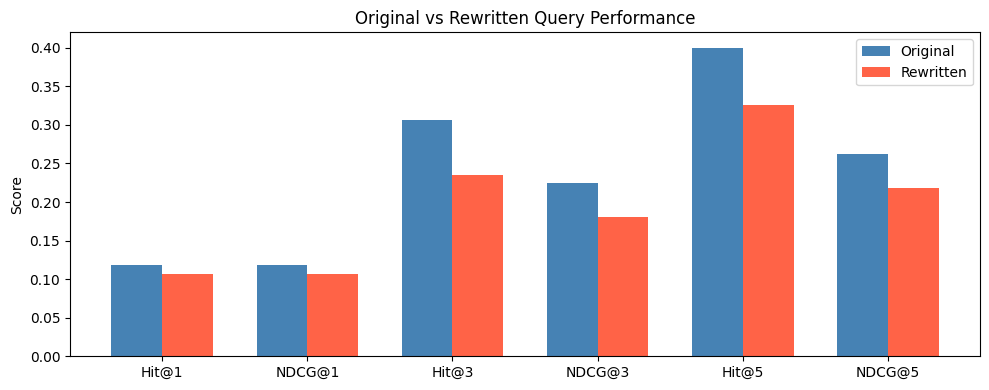

In [47]:
#visualisation
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(comparison.columns))
width = 0.35

bars1 = ax.bar(x - width/2, comparison.loc['Dense (original)'], width, label='Original', color='steelblue')
bars2 = ax.bar(x + width/2, comparison.loc['Dense (rewritten)'], width, label='Rewritten', color='tomato')

ax.set_xticks(x)
ax.set_xticklabels(comparison.columns)
ax.set_ylabel('Score')
ax.set_title('Original vs Rewritten Query Performance')
ax.legend()
plt.tight_layout()
plt.savefig('fig_rewriting_comparison.png', dpi=300)
plt.show()

In [48]:
# I will use HyDE method which was given in RAG slides
HYDE_PROMPT = """You are an expert in ISO/IEC 5338:2023 AI system life cycle processes.
Given a technical debt case from an AI project, write a short paragraph describing which ISO 5338 process this case belongs to and why.
Write it as if you are describing the process itself — in the style of an ISO standard process description.

Rules:
- Output ONE paragraph only. No questions, no bullet points, no preamble.
- Describe the relevant process activities, outcomes, and artefacts.
- Do NOT mention the technical debt case explicitly."""

def hyde_query(case_description, root_cause):
    rc_text = root_cause if str(root_cause) != '-' else ''
    prompt = f"{HYDE_PROMPT}\n\nCase description: {case_description}\nRoot cause: {rc_text}"
    
    response = requests.post(
        "http://localhost:11434/api/generate",
        json={
            "model": "llama3.2",
            "prompt": prompt,
            "stream": False
        }
    )
    return response.json()['response'].strip()

# Test
print(hyde_query("Inability to obtain the data scraped from commercial sites", 
                 "Data formats change over time in the third-party data source"))

The identified issue falls under the "Data Management" phase of the AI system life cycle, specifically within the "Data Acquisition and Integration" process (ISO/IEC 5338-3). This phase involves planning, acquiring, integrating, validating, and maintaining data from various sources to support AI system development. In this case, the issue arises due to a change in the data format of the third-party data source, leading to difficulties in obtaining the required data for the AI system's operation. The outcome is an inability to perform the intended task, and relevant artefacts include updated requirements documentation, revised data acquisition plans, and potentially modified data processing scripts.


In [49]:
#now for the all dataset
hyde_queries = []
for _, row in tqdm(df.iterrows(), total = len(df)):
    hq=hyde_query(row['case_description'], row['root_cause'])
    hyde_queries.append(hq)

df['hyde_query'] = hyde_queries
print("done")
print(df[['query', 'hyde_query']].head(2).to_string())

100%|████████████████████████████████████████████████████████████████████████████████| 365/365 [06:34<00:00,  1.08s/it]


done
                                                                                                                     query                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           hyde_query
0  Inability to obtain the data scraped from commercial sites Data formats change over time in the third-party data

In [50]:
#embed and calc the metrics
hyde_embeddings = model.encode(df['hyde_query'].tolist(), convert_to_tensor=True, show_progress_bar=True)

hyde_cosine = util.cos_sim(hyde_embeddings, doc_embeddings)
hyde_ranked = torch.argsort(hyde_cosine, dim=1, descending=True).cpu().numpy()

hyde_metrics = compute_metrics(hyde_ranked, golden_ids)
print("HyDE metrics (alpha=0):")
for k, v in hyde_metrics.items():
    print(f"  {k}: {v:.4f}")

Batches:   0%|          | 0/12 [00:00<?, ?it/s]

HyDE metrics (alpha=0):
  Hit@1: 0.0658
  NDCG@1: 0.0658
  Hit@3: 0.1945
  NDCG@3: 0.1413
  Hit@5: 0.2685
  NDCG@5: 0.1712


In [51]:
#compare the approaches
comparison = pd.DataFrame({
    'Dense (original)':  dense_metrics,
    'Dense (rewritten)': rw_metrics,
    'HyDE':              hyde_metrics,
}).T
print(comparison.to_string())

                      Hit@1    NDCG@1     Hit@3    NDCG@3     Hit@5    NDCG@5
Dense (original)   0.117808  0.117808  0.306849  0.224525  0.400000  0.262722
Dense (rewritten)  0.106849  0.106849  0.235616  0.180201  0.326027  0.217578
HyDE               0.065753  0.065753  0.194521  0.141257  0.268493  0.171194


In [52]:
print("Failure case analysis: original vs rewritten vs HyDE")
print()
for fc in selected_failures:
    i = fc['row_idx']
    gid = golden_ids[i]
    orig_rank = list(ranked_indices[i]).index(gid) + 1
    rw_rank   = list(rw_ranked[i]).index(gid) + 1
    hyde_rank = list(hyde_ranked[i]).index(gid) + 1
    print(f"Row {i:3d} | {fc['golden_doc']}")
    print(f" Original: {orig_rank}  →  Rewritten: {rw_rank}  →  HyDE: {hyde_rank}")
    print()

Failure case analysis: original vs rewritten vs HyDE

Row   0 | Design Definition Process (6.4.5)
 Original: 26  →  Rewritten: 32  →  HyDE: 1

Row   2 | Decision Management Process (6.3.3)
 Original: 13  →  Rewritten: 12  →  HyDE: 9

Row   3 | Validation Process (6.4.13)
 Original: 6  →  Rewritten: 16  →  HyDE: 2

Row   4 | AI Data Engineering Process (6.4.8)
 Original: 14  →  Rewritten: 5  →  HyDE: 10

Row   8 | System Requirements Definition Process (6.4.3)
 Original: 8  →  Rewritten: 23  →  HyDE: 17



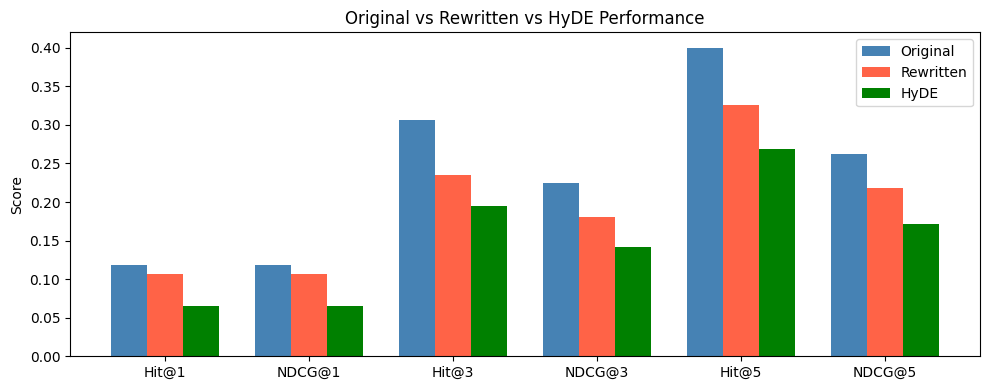

In [53]:
#comparison graph again
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(comparison.columns))
width = 0.25

ax.bar(x - width, comparison.loc['Dense (original)'], width, label='Original', color='steelblue')
ax.bar(x, comparison.loc['Dense (rewritten)'], width, label='Rewritten', color='tomato')
ax.bar(x + width, comparison.loc['HyDE'], width, label='HyDE', color='green')

ax.set_xticks(x)
ax.set_xticklabels(comparison.columns)
ax.set_ylabel('Score')
ax.set_title('Original vs Rewritten vs HyDE Performance')
ax.legend()
plt.tight_layout()
plt.savefig('fig_rewriting_comparison.png', dpi=300)
plt.show()

In [57]:
#TEST SET
df_test = pd.read_csv('td_cases_test_4.csv')
df_test = df_test.rename(columns={'unnamed: 0': 'idx'})
df_test['query']=df_test.apply(query_text, axis=1)

print(df_test.shape)
df_test.head(3)

(157, 6)


,Unnamed: 0,case_description,root_cause,golden_doc,golden_id,query
0,0,Excessive use of containerization to achieve d...,Over-prioritization of isolation requirements ...,Design Definition Process (6.4.5),20,Excessive use of containerization to achieve d...
1,1,Out-of-distribution (OOD) examples,"Adversarial attacks by phishers, with spam con...",AI Data Engineering Process (6.4.8),23,Out-of-distribution (OOD) examples Adversarial...
2,2,Potential loss of model and training progress ...,Lack of experiment tracking which will let to ...,Configuration Management Process (6.3.5),12,Potential loss of model and training progress ...


In [58]:
#calculating the metrics with dense retrieval

test_golden_ids = df_test['golden_id'].tolist()

test_embs = model.encode(df_test['query'].tolist(), convert_to_tensor=True, show_progress_bar=True)
test_cosine = util.cos_sim(test_embs, doc_embeddings)
test_ranked_dense = torch.argsort(test_cosine, dim=1, descending=True).cpu().numpy()

test_dense_metrics = compute_metrics(test_ranked_dense, test_golden_ids)
print("Test Dense Metrics (alpha=0):")
for k, v in test_dense_metrics.items():
    print(f"  {k}: {v:.4f}")

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

Test Dense Metrics (alpha=0):
  Hit@1: 0.0764
  NDCG@1: 0.0764
  Hit@3: 0.1783
  NDCG@3: 0.1316
  Hit@5: 0.2994
  NDCG@5: 0.1820


In [59]:
test_ranked_hybrid = []
for i, row in df_test.iterrows():
    ranked = hybrid_retrieve(row['query'], test_embs[i], best_alpha, bm25, doc_embeddings)
    test_ranked_hybrid.append(ranked)

test_hybrid_metrics = compute_metrics(test_ranked_hybrid, test_golden_ids)
print(f"Test Hybrid Metrics (alpha={best_alpha}):")
for k, v in test_hybrid_metrics.items():
    print(f"  {k}: {v:.4f}")

Test Hybrid Metrics (alpha=0.0):
  Hit@1: 0.0764
  NDCG@1: 0.0764
  Hit@3: 0.1783
  NDCG@3: 0.1316
  Hit@5: 0.2994
  NDCG@5: 0.1820


In [60]:
#now i will rewrtie the test set
test_rw_queries = []
for _, row in tqdm(df_test.iterrows(), total=len(df_test)):
    rq = rewrite_query(row['case_description'], row['root_cause'])
    test_rw_queries.append(rq)

df_test['rewritten_query']=test_rw_queries
print('done')

100%|████████████████████████████████████████████████████████████████████████████████| 157/157 [00:57<00:00,  2.71it/s]


done


In [62]:
test_rw_embs=model.encode(df_test['rewritten_query'].tolist(),convert_to_tensor=True, show_progress_bar=True)
test_rw_cosine=util.cos_sim(test_rw_embs, doc_embeddings)
test_ranked_rw=torch.argsort(test_rw_cosine, dim=1, descending=True).cpu().numpy()

test_rw_metrics=compute_metrics(test_ranked_rw, test_golden_ids)
print("test rewritten metrics (alpha=0)")
for k, v in test_rw_metrics.items():
    print(f"  {k}: {v:.4f}")

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

test rewritten metrics (alpha=0)
  Hit@1: 0.0892
  NDCG@1: 0.0892
  Hit@3: 0.1911
  NDCG@3: 0.1460
  Hit@5: 0.2675
  NDCG@5: 0.1778


In [63]:
#test hyde
test_hyde_queries = []
for _, row in tqdm(df_test.iterrows(), total=len(df_test)):
    hq = hyde_query(row['case_description'], row['root_cause'])
    test_hyde_queries.append(hq)

df_test['hyde_query'] = test_hyde_queries
print("done")

100%|████████████████████████████████████████████████████████████████████████████████| 157/157 [02:48<00:00,  1.07s/it]


done


In [64]:
test_hyde_embs = model.encode(df_test['hyde_query'].tolist(), convert_to_tensor=True, show_progress_bar=True)
test_hyde_cosine = util.cos_sim(test_hyde_embs, doc_embeddings)
test_ranked_hyde = torch.argsort(test_hyde_cosine, dim=1, descending=True).cpu().numpy()

test_hyde_metrics = compute_metrics(test_ranked_hyde, test_golden_ids)
print("Test HyDE Metrics (alpha=0):")
for k, v in test_hyde_metrics.items():
    print(f"  {k}: {v:.4f}")

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

Test HyDE Metrics (alpha=0):
  Hit@1: 0.0382
  NDCG@1: 0.0382
  Hit@3: 0.1592
  NDCG@3: 0.1054
  Hit@5: 0.3121
  NDCG@5: 0.1684


In [65]:
test_comparison = pd.DataFrame({
    'Dense (original)':  test_dense_metrics,
    'Dense (rewritten)': test_rw_metrics,
    'HyDE':              test_hyde_metrics,
}).T
print("TEST SET:")
print(test_comparison.to_string())
print()
print("TRAIN SET:")
print(comparison.to_string())

TEST SET:
                      Hit@1    NDCG@1     Hit@3    NDCG@3     Hit@5    NDCG@5
Dense (original)   0.076433  0.076433  0.178344  0.131558  0.299363  0.182004
Dense (rewritten)  0.089172  0.089172  0.191083  0.145965  0.267516  0.177766
HyDE               0.038217  0.038217  0.159236  0.105398  0.312102  0.168442

TRAIN SET:
                      Hit@1    NDCG@1     Hit@3    NDCG@3     Hit@5    NDCG@5
Dense (original)   0.117808  0.117808  0.306849  0.224525  0.400000  0.262722
Dense (rewritten)  0.106849  0.106849  0.235616  0.180201  0.326027  0.217578
HyDE               0.065753  0.065753  0.194521  0.141257  0.268493  0.171194


In [66]:
test_failure_cases = []
for i, (ranked, gid) in enumerate(zip(test_ranked_dense, test_golden_ids)):
    rank = list(ranked).index(gid) + 1
    if rank > 5:
        test_failure_cases.append({
            'row_idx': i,
            'golden_rank': rank,
            'golden_doc': df_test.iloc[i]['golden_doc'],
            'top1_doc': doc_keys[ranked[0]],
            'case_description': df_test.iloc[i]['case_description'],
            'root_cause': df_test.iloc[i]['root_cause'],
        })

print(f"Total test failure cases (rank > 5): {len(test_failure_cases)}")
print()
for fc in test_failure_cases[:5]:
    rw_rank   = list(test_ranked_rw[fc['row_idx']]).index(test_golden_ids[fc['row_idx']]) + 1
    hyde_rank = list(test_ranked_hyde[fc['row_idx']]).index(test_golden_ids[fc['row_idx']]) + 1
    print(f"Row {fc['row_idx']:3d} | {fc['golden_doc']}")
    print(f"         Original: {fc['golden_rank']}  →  Rewritten: {rw_rank}  →  HyDE: {hyde_rank}")
    print(f"         Case: {fc['case_description'][:60]}")
    print()

Total test failure cases (rank > 5): 110

Row   0 | Design Definition Process (6.4.5)
         Original: 11  →  Rewritten: 13  →  HyDE: 6
         Case: Excessive use of containerization to achieve deployment isol

Row   3 | AI Data Engineering Process (6.4.8)
         Original: 8  →  Rewritten: 3  →  HyDE: 9
         Case: Empty values in the dataset

Row   5 | AI Data Engineering Process (6.4.8)
         Original: 7  →  Rewritten: 7  →  HyDE: 26
         Case: Missing downstream data during time series forecasting

Row   8 | Quality Assurance Process (6.3.8)
         Original: 7  →  Rewritten: 21  →  HyDE: 16
         Case: Having noisy data

Row  11 | System Requirements Definition Process (6.4.3)
         Original: 27  →  Rewritten: 29  →  HyDE: 26
         Case: No previously labeled data



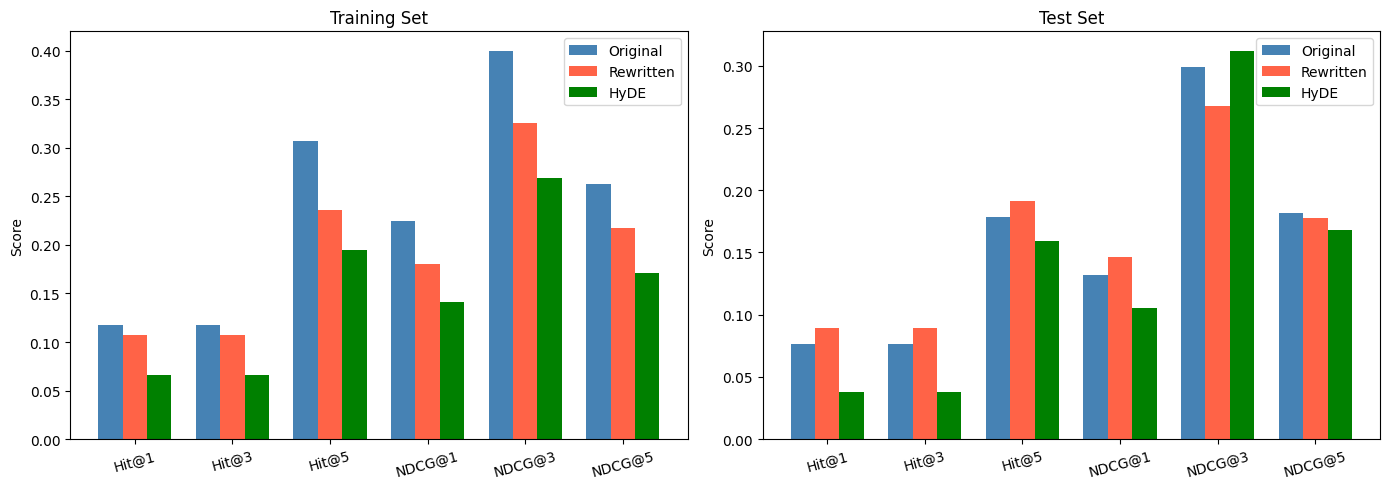

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics_list = ['Hit@1', 'Hit@3', 'Hit@5', 'NDCG@1', 'NDCG@3', 'NDCG@5']
x = np.arange(len(metrics_list))
width = 0.25

for ax, (comp, title) in zip(axes, [(comparison, 'Training Set'), (test_comparison, 'Test Set')]):
    ax.bar(x - width, comp.loc['Dense (original)'], width, label='Original', color='steelblue')
    ax.bar(x, comp.loc['Dense (rewritten)'], width, label='Rewritten', color='tomato')
    ax.bar(x + width, comp.loc['HyDE'], width, label='HyDE', color='green')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics_list, rotation=15)
    ax.set_ylabel('Score')
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.savefig('fig_train_vs_test.png', dpi=300)
plt.show()